In [1]:
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="project")
import censusgeocode as cg

hist=pd.read_csv('CHAT-Los Angeles County-historical.csv', index_col=0)
vuln=pd.read_csv('CHAT-Los Angeles County-vulnerability-indicators.csv', index_col=0)

bev_hist = pd.read_csv('CHAT-Beverly Hills-historical.csv', index_col=0)
compt_hist = pd.read_csv('CHAT-Compton-historical.csv', index_col=0)
bev_vuln = pd.read_csv('CHAT-Beverly Hills-vulnerability-indicators.csv', index_col=0)
compt_vuln = pd.read_csv('CHAT-Compton-vulnerability-indicators.csv', index_col=0)

malibu = pd.read_csv('CHAT-Malibu-vulnerability-indicators.csv', index_col=0)
hawthorne = pd.read_csv('CHAT-Hawthorne-vulnerability-indicators.csv', index_col=0)
mh = pd.concat([malibu, hawthorne], axis = 0)

westhollywood = pd.read_csv('CHAT-West Hollywood-vulnerability-indicators.csv', index_col=0)
elmonte = pd.read_csv('CHAT-El Monte-vulnerability-indicators.csv', index_col=0)
west_el = pd.concat([westhollywood, elmonte], axis = 0)

bev = bev_hist.merge(bev_vuln, how = 'inner')
compt = compt_hist.merge(compt_vuln, how = 'inner')
bev_compt = pd.concat([bev, compt], axis = 0)

In [2]:
cg.coordinates(x=-118, y=34)

{'States': [{'STATENS': '01779778',
   'GEOID': '06',
   'CENTLAT': '+37.1547616',
   'AREAWATER': '20290471105',
   'STATE': '06',
   'BASENAME': 'California',
   'STUSAB': 'CA',
   'OID': '2749018475066',
   'LSADC': '00',
   'FUNCSTAT': 'A',
   'INTPTLAT': '+37.1551773',
   'DIVISION': '9',
   'NAME': 'California',
   'REGION': '4',
   'OBJECTID': 41,
   'CENTLON': '-119.5277735',
   'AREALAND': '403674598069',
   'INTPTLON': '-119.5434183',
   'MTFCC': 'G4000',
   'CENT': (-119.5277735, 37.1547616),
   'INTPT': (-119.5434183, 37.1551773)}],
 'Combined Statistical Areas': [{'POP100': '',
   'GEOID': '348',
   'CENTLAT': '+34.4706964',
   'AREAWATER': '3476817946',
   'BASENAME': 'Los Angeles-Long Beach, CA',
   'OID': '2619034687908066',
   'LSADC': 'M0',
   'FUNCSTAT': 'S',
   'INTPTLAT': '+34.4637584',
   'NAME': 'Los Angeles-Long Beach, CA CSA',
   'OBJECTID': 28,
   'CSA': '348',
   'CENTLON': '-116.6480322',
   'INTPTLON': '-116.6585523',
   'AREALAND': '87986126435',
   'HU100

In [3]:
#Functions to find latitude and longitude, given a city in California. Since the library is limited to only one search per second, I needed to include
#a one second delay.
def lati(x):
  lat = geolocator.geocode(x + ", CA").latitude
  time.sleep(1)
  return lat
def long(x):
  lon = geolocator.geocode(x + ", CA").longitude
  time.sleep(1)
  return lon

In [4]:
#Creates a DataFrame with each city's maximum value and adds the lat and lon to it.
#This block of code will take around 5 minutes to run because of the one second delay per lat and lon.
vuln_group = vuln.groupby('census_city').max().reset_index().dropna()

vuln_group['lat'] = vuln_group['census_city']
vuln_group['lon'] = vuln_group['census_city']
vuln_group['lat'] = vuln_group['lat'].apply(lambda x:lati(x))
vuln_group['lon'] = vuln_group['lon'].apply(lambda x:long(x))

vuln_group.at[109,'lat'] = 34.4131941
vuln_group.at[109,'lon'] = -118.5598491

vuln_group

,census_city,census_county,heat_health_action_index,perc_children,perc_no_hs_diploma,perc_elderly,perc_outdoor_workers,tract_population,perc_poverty,perc_two_races,...,perc_ambulatory_disability,perc_cognitive_disability,pm25_concentration,perc_impervious_surfaces,change_in_dev,perc_no_tree_canopy,uhii_avgdeltat,ozone_exceedance,lat,lon
1,Agoura Hills,Los Angeles County,20.21,4.0,12.4,16.1,2.16,6571.0,13.4,5.0,...,4.2,3.3,10.61,39.06,34.53,92.80,1.48,0.01,34.148169,-118.765546
2,Alhambra,Los Angeles County,45.37,6.3,34.0,32.2,7.40,5648.0,27.3,2.7,...,7.9,6.8,12.70,75.09,0.00,94.87,3.46,0.07,34.093042,-118.127060
3,Altadena,Los Angeles County,35.02,6.1,25.4,19.2,9.24,6608.0,18.7,5.0,...,9.1,6.4,12.06,41.21,30.86,93.66,7.59,0.16,34.192819,-118.137466
4,Arcadia,Los Angeles County,34.88,6.4,13.6,22.2,3.84,6934.0,12.0,5.4,...,6.0,4.3,12.66,72.89,14.64,93.89,6.19,0.19,34.136207,-118.040150
5,Artesia,Los Angeles County,44.22,7.2,39.2,15.8,3.12,7287.0,13.7,3.1,...,7.6,7.6,12.13,76.17,0.00,96.41,1.60,0.01,33.869020,-118.079620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,West Hollywood,Los Angeles County,33.03,4.9,3.9,14.7,3.51,5679.0,16.4,5.8,...,5.8,4.1,12.31,74.26,19.45,95.33,1.63,0.03,34.092301,-118.369289
118,Westlake Village,Los Angeles County,20.46,6.9,3.2,28.8,1.24,6414.0,8.4,5.0,...,9.4,7.0,10.18,44.04,34.97,93.26,1.26,0.01,34.146023,-118.806179
119,Whittier,Los Angeles County,57.65,10.9,43.5,18.3,12.36,7631.0,37.1,4.0,...,10.1,9.0,12.83,72.18,34.49,96.53,2.76,0.04,33.974914,-118.033866
120,Wilmington,Los Angeles County,70.69,14.6,61.9,11.6,16.70,5559.0,46.2,6.8,...,13.9,5.9,11.58,79.44,2.68,97.37,0.99,0.00,33.780016,-118.262509


In [5]:
vuln2 = vuln_group
vuln2['poverty'] = vuln2.perc_poverty
vuln2['poverty'] = vuln2.poverty.apply(lambda x:'Above' if x > 11.6 else 'Below')
vuln2

,census_city,census_county,heat_health_action_index,perc_children,perc_no_hs_diploma,perc_elderly,perc_outdoor_workers,tract_population,perc_poverty,perc_two_races,...,perc_cognitive_disability,pm25_concentration,perc_impervious_surfaces,change_in_dev,perc_no_tree_canopy,uhii_avgdeltat,ozone_exceedance,lat,lon,poverty
1,Agoura Hills,Los Angeles County,20.21,4.0,12.4,16.1,2.16,6571.0,13.4,5.0,...,3.3,10.61,39.06,34.53,92.80,1.48,0.01,34.148169,-118.765546,Above
2,Alhambra,Los Angeles County,45.37,6.3,34.0,32.2,7.40,5648.0,27.3,2.7,...,6.8,12.70,75.09,0.00,94.87,3.46,0.07,34.093042,-118.127060,Above
3,Altadena,Los Angeles County,35.02,6.1,25.4,19.2,9.24,6608.0,18.7,5.0,...,6.4,12.06,41.21,30.86,93.66,7.59,0.16,34.192819,-118.137466,Above
4,Arcadia,Los Angeles County,34.88,6.4,13.6,22.2,3.84,6934.0,12.0,5.4,...,4.3,12.66,72.89,14.64,93.89,6.19,0.19,34.136207,-118.040150,Above
5,Artesia,Los Angeles County,44.22,7.2,39.2,15.8,3.12,7287.0,13.7,3.1,...,7.6,12.13,76.17,0.00,96.41,1.60,0.01,33.869020,-118.079620,Above
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,West Hollywood,Los Angeles County,33.03,4.9,3.9,14.7,3.51,5679.0,16.4,5.8,...,4.1,12.31,74.26,19.45,95.33,1.63,0.03,34.092301,-118.369289,Above
118,Westlake Village,Los Angeles County,20.46,6.9,3.2,28.8,1.24,6414.0,8.4,5.0,...,7.0,10.18,44.04,34.97,93.26,1.26,0.01,34.146023,-118.806179,Below
119,Whittier,Los Angeles County,57.65,10.9,43.5,18.3,12.36,7631.0,37.1,4.0,...,9.0,12.83,72.18,34.49,96.53,2.76,0.04,33.974914,-118.033866,Above
120,Wilmington,Los Angeles County,70.69,14.6,61.9,11.6,16.70,5559.0,46.2,6.8,...,5.9,11.58,79.44,2.68,97.37,0.99,0.00,33.780016,-118.262509,Above


In [6]:
#Making a DataFrame with just the cities and the lat and lon
coords = vuln_group.set_index('census_city')
coords = coords[['lat', 'lon']]
coords.at['Valencia', 'lat'] = 34.4131941
coords.at['Valencia', 'lon'] =  -118.5598491

In [7]:
#Function to get the size of each city based on lat and lon
#Adds the size to the DataFrame
def size(lat, lon):
    results = cg.coordinates(x=lon, y=lat)
    
    # Check if "Incorporated Places" exists and is non-empty
    if "Incorporated Places" in results and results["Incorporated Places"]:
        return results["Incorporated Places"][0].get("AREALAND")
    
    # If not, check for "Census Designated Places"
    elif "Census Designated Places" in results and results["Census Designated Places"]:
        return results["Census Designated Places"][0].get("AREALAND")
    
    # If neither are available, return 0
    return 0

vuln_group['size'] = vuln_group['lat']
vuln_group['size'] = vuln_group.apply(lambda x:size(x.lat, x.lon), axis=1)
vuln_group

,census_city,census_county,heat_health_action_index,perc_children,perc_no_hs_diploma,perc_elderly,perc_outdoor_workers,tract_population,perc_poverty,perc_two_races,...,pm25_concentration,perc_impervious_surfaces,change_in_dev,perc_no_tree_canopy,uhii_avgdeltat,ozone_exceedance,lat,lon,poverty,size
1,Agoura Hills,Los Angeles County,20.21,4.0,12.4,16.1,2.16,6571.0,13.4,5.0,...,10.61,39.06,34.53,92.80,1.48,0.01,34.148169,-118.765546,Above,20191599
2,Alhambra,Los Angeles County,45.37,6.3,34.0,32.2,7.40,5648.0,27.3,2.7,...,12.70,75.09,0.00,94.87,3.46,0.07,34.093042,-118.127060,Above,19764463
3,Altadena,Los Angeles County,35.02,6.1,25.4,19.2,9.24,6608.0,18.7,5.0,...,12.06,41.21,30.86,93.66,7.59,0.16,34.192819,-118.137466,Above,21924372
4,Arcadia,Los Angeles County,34.88,6.4,13.6,22.2,3.84,6934.0,12.0,5.4,...,12.66,72.89,14.64,93.89,6.19,0.19,34.136207,-118.040150,Above,28300614
5,Artesia,Los Angeles County,44.22,7.2,39.2,15.8,3.12,7287.0,13.7,3.1,...,12.13,76.17,0.00,96.41,1.60,0.01,33.869020,-118.079620,Above,4196986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,West Hollywood,Los Angeles County,33.03,4.9,3.9,14.7,3.51,5679.0,16.4,5.8,...,12.31,74.26,19.45,95.33,1.63,0.03,34.092301,-118.369289,Above,4888800
118,Westlake Village,Los Angeles County,20.46,6.9,3.2,28.8,1.24,6414.0,8.4,5.0,...,10.18,44.04,34.97,93.26,1.26,0.01,34.146023,-118.806179,Below,13434930
119,Whittier,Los Angeles County,57.65,10.9,43.5,18.3,12.36,7631.0,37.1,4.0,...,12.83,72.18,34.49,96.53,2.76,0.04,33.974914,-118.033866,Above,37940442
120,Wilmington,Los Angeles County,70.69,14.6,61.9,11.6,16.70,5559.0,46.2,6.8,...,11.58,79.44,2.68,97.37,0.99,0.00,33.780016,-118.262509,Above,1218637164


In [8]:
#Makes the mapbox
vuln_group['size'] = pd.to_numeric(vuln_group['size'], errors='coerce')

pmc_la = px.scatter_map(vuln_group,
                  lat='lat',
                  lon='lon',
                  map_style='carto-positron',
                  color='pm25_concentration',
                  zoom=7.4,
                  size='size',
                  size_max = 25,
                  color_continuous_scale='icefire',
                  hover_data={'lat':False,'lon':False, 'size':False, 'census_city':True},
                  opacity=.75,
                  title='Particulate Matter Concentration in each LA city',
                  width = 800,
                  height = 540)
pmc_la.write_image("pmc_la.png")

![plot](pmc_la.png)

In [11]:
vuln_group2 = vuln_group
vuln_group2['perc_poverty'] = vuln_group2.perc_poverty.apply(lambda x:x * -1)
vuln_group2

,census_city,census_county,heat_health_action_index,perc_children,perc_no_hs_diploma,perc_elderly,perc_outdoor_workers,tract_population,perc_poverty,perc_two_races,...,pm25_concentration,perc_impervious_surfaces,change_in_dev,perc_no_tree_canopy,uhii_avgdeltat,ozone_exceedance,lat,lon,poverty,size
1,Agoura Hills,Los Angeles County,20.21,4.0,12.4,16.1,2.16,6571.0,13.4,5.0,...,10.61,39.06,34.53,92.80,1.48,0.01,34.148169,-118.765546,Above,20191599
2,Alhambra,Los Angeles County,45.37,6.3,34.0,32.2,7.40,5648.0,27.3,2.7,...,12.70,75.09,0.00,94.87,3.46,0.07,34.093042,-118.127060,Above,19764463
3,Altadena,Los Angeles County,35.02,6.1,25.4,19.2,9.24,6608.0,18.7,5.0,...,12.06,41.21,30.86,93.66,7.59,0.16,34.192819,-118.137466,Above,21924372
4,Arcadia,Los Angeles County,34.88,6.4,13.6,22.2,3.84,6934.0,12.0,5.4,...,12.66,72.89,14.64,93.89,6.19,0.19,34.136207,-118.040150,Above,28300614
5,Artesia,Los Angeles County,44.22,7.2,39.2,15.8,3.12,7287.0,13.7,3.1,...,12.13,76.17,0.00,96.41,1.60,0.01,33.869020,-118.079620,Above,4196986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,West Hollywood,Los Angeles County,33.03,4.9,3.9,14.7,3.51,5679.0,16.4,5.8,...,12.31,74.26,19.45,95.33,1.63,0.03,34.092301,-118.369289,Above,4888800
118,Westlake Village,Los Angeles County,20.46,6.9,3.2,28.8,1.24,6414.0,8.4,5.0,...,10.18,44.04,34.97,93.26,1.26,0.01,34.146023,-118.806179,Below,13434930
119,Whittier,Los Angeles County,57.65,10.9,43.5,18.3,12.36,7631.0,37.1,4.0,...,12.83,72.18,34.49,96.53,2.76,0.04,33.974914,-118.033866,Above,37940442
120,Wilmington,Los Angeles County,70.69,14.6,61.9,11.6,16.70,5559.0,46.2,6.8,...,11.58,79.44,2.68,97.37,0.99,0.00,33.780016,-118.262509,Above,1218637164


In [12]:
asthma_prev = px.scatter_map(vuln_group2,
                  lat='lat',
                  lon='lon',
                  map_style='carto-positron',
                  color='asthma_prevalence',
                  zoom=7.4,
                  size='perc_poverty',
                  hover_data={'lat':False,'lon':False, 'size':False, 'census_city':True},
                  opacity=.75,
                  title='Asthma Prevalence in each LA city',
                  width = 800,
                  height = 540)
asthma_prev.write_image("asthma_prev.png")

![plot](asthma_prev.png)


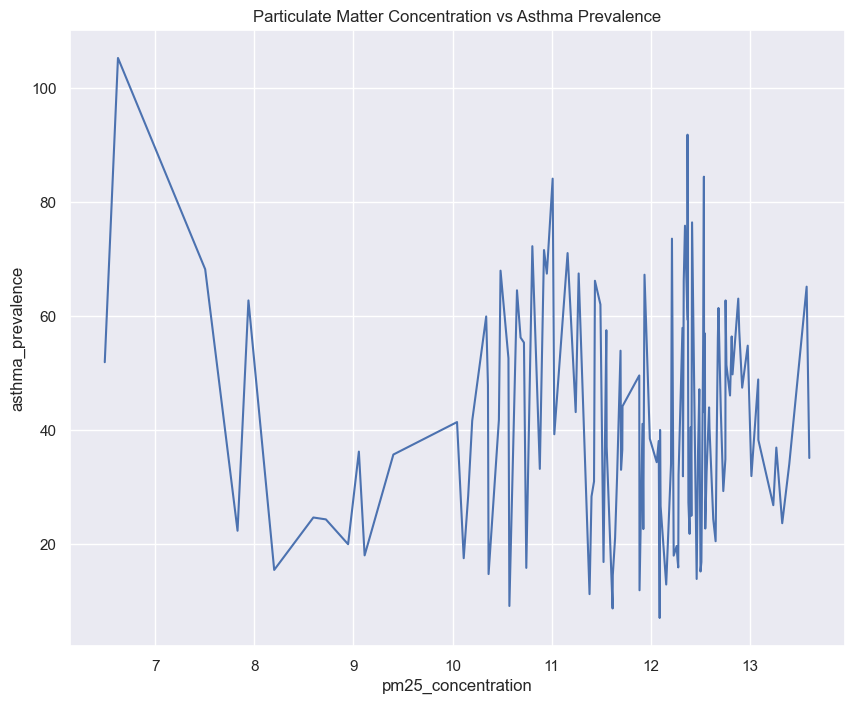

In [13]:
avg_vuln = vuln.groupby('census_city', as_index=False).mean(numeric_only=True)

sns.set_theme()
fig,ax=plt.subplots()
ax=sns.lineplot(data=avg_vuln,x='pm25_concentration',y='asthma_prevalence')
ax.set_title('Particulate Matter Concentration vs Asthma Prevalence')
fig.set_size_inches(10,8)

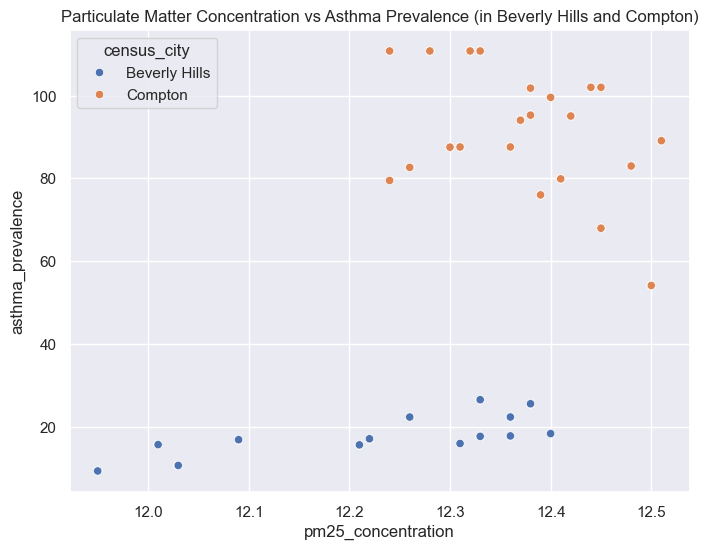

In [14]:
fig,ax=plt.subplots()
ax=sns.scatterplot(data=bev_compt,x='pm25_concentration',y='asthma_prevalence', hue='census_city')
ax.set_title('Particulate Matter Concentration vs Asthma Prevalence (in Beverly Hills and Compton)')
fig.set_size_inches((8,6))

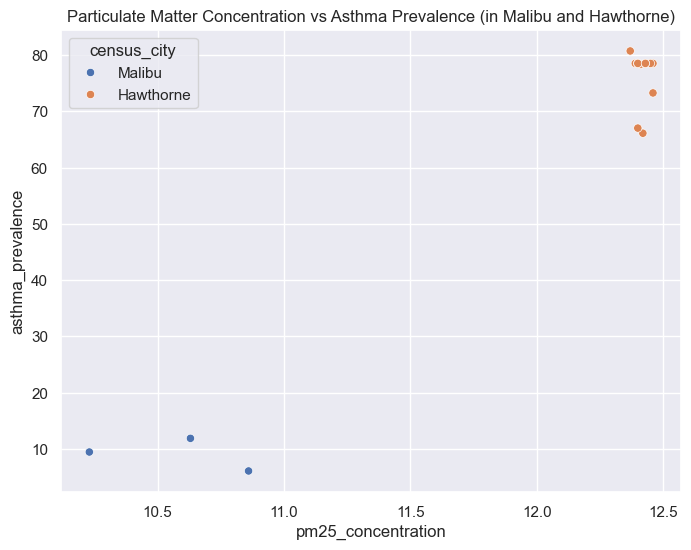

In [15]:
fig,ax=plt.subplots()
ax=sns.scatterplot(data=mh,x='pm25_concentration',y='asthma_prevalence', hue='census_city')
ax.set_title('Particulate Matter Concentration vs Asthma Prevalence (in Malibu and Hawthorne)')
fig.set_size_inches((8,6))

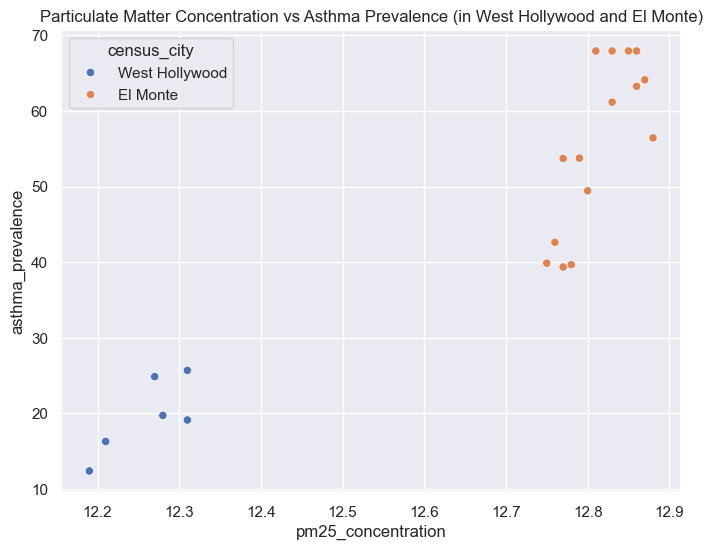

In [16]:
fig,ax=plt.subplots()
ax=sns.scatterplot(data=west_el,x='pm25_concentration',y='asthma_prevalence', hue='census_city')
ax.set_title('Particulate Matter Concentration vs Asthma Prevalence (in West Hollywood and El Monte)')
fig.set_size_inches((8,6))

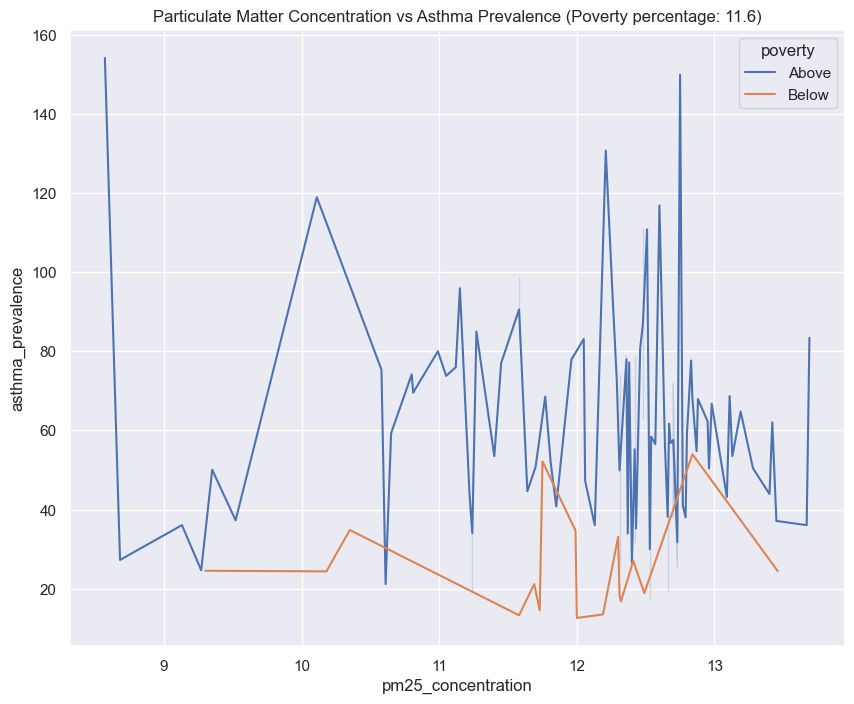

In [17]:
fig,ax=plt.subplots()
ax = sns.lineplot(data=vuln2,x='pm25_concentration',y='asthma_prevalence', hue = 'poverty')
ax.set_title('Particulate Matter Concentration vs Asthma Prevalence (Poverty percentage: 11.6)')
fig.set_size_inches(10,8)

In [18]:
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hist=pd.read_csv('CHAT-Los Angeles County-historical.csv', index_col=0)
vuln=pd.read_csv('CHAT-Los Angeles County-vulnerability-indicators.csv', index_col=0)
#hist_vuln = hist.merge()

In [19]:
hist_temp=(hist[hist.socioeconomic_group=='2006 HW']
           .groupby('census_city', as_index=False).mean(numeric_only=True)
           .reset_index()[['census_city','tmax','tmin']])
hist_temp['tavg']=(hist_temp.tmax+hist_temp.tmin)/2
hist_temp

,census_city,tmax,tmin,tavg
0,Acton,103.620000,75.016667,89.318333
1,Agoura Hills,100.202857,72.072857,86.137857
2,Alhambra,102.570000,73.060000,87.815000
3,Altadena,104.340000,74.590000,89.465000
4,Arcadia,105.080000,73.150000,89.115000
...,...,...,...,...
122,Westlake Village,94.190000,70.470000,82.330000
123,Whittier,101.880000,72.340000,87.110000
124,Wilmington,90.690000,72.050000,81.370000
125,Winnetka,107.076000,74.506000,90.791000


In [20]:
vuln

,census_county,census_city,heat_health_action_index,perc_children,perc_no_hs_diploma,perc_elderly,perc_outdoor_workers,tract_population,perc_poverty,perc_two_races,...,perc_low_birth_weight,cardio_disease_prevalence,perc_ambulatory_disability,perc_cognitive_disability,pm25_concentration,perc_impervious_surfaces,change_in_dev,perc_no_tree_canopy,uhii_avgdeltat,ozone_exceedance
census_tract,,,,,,,,,,,,,,,,,,,,,
6037101110,Los Angeles County,Tujunga,36.53,4.9,19.7,13.4,6.57,4824.0,14.5,1.8,...,3.44,10.81,7.4,5.0,11.04,43.11,0.00,94.14,2.26,0.19
6037101122,Los Angeles County,Tujunga,19.76,1.7,4.7,15.5,7.68,3291.0,2.7,1.7,...,5.05,8.87,3.9,2.0,10.95,25.36,12.44,90.80,NaN,0.19
6037101210,Los Angeles County,Tujunga,43.45,3.9,22.8,8.8,8.38,5882.0,24.0,4.7,...,4.89,10.81,8.2,5.2,11.11,56.99,0.00,95.99,NaN,0.18
6037101220,Los Angeles County,Tujunga,40.68,4.7,17.8,11.8,4.80,2902.0,14.2,3.6,...,4.27,10.81,10.4,5.1,11.14,45.24,0.00,95.35,NaN,0.18
6037101300,Los Angeles County,La Crescenta,23.03,2.5,10.1,20.2,8.01,4410.0,7.3,0.9,...,3.48,8.16,7.4,2.9,11.19,36.00,25.15,92.52,NaN,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6037980028,Los Angeles County,Playa del Rey,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,7.12,NaN,NaN,12.43,88.34,2.13,98.77,NaN,0.00
6037980030,Los Angeles County,El Segundo,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN
6037980031,Los Angeles County,Wilmington,38.32,0.0,18.7,7.1,0.00,1035.0,0.0,1.7,...,NaN,9.39,0.0,0.0,10.91,66.92,1.07,92.99,0.33,0.00


In [21]:
vuln=vuln.rename(columns={"heat_health_action_index": "heat vulnerability", 'perc_children':'young', 'perc_elderly':'elderly', 'perc_poverty':'poverty','perc_two_races':'racial minorities','perc_linguistic_isolation':'language minorities' })
vuln_avg=(vuln.groupby('census_city', as_index=False).mean(numeric_only=True).
          reset_index()[['census_city','young','elderly','poverty','racial minorities','language minorities']])
vuln_indi=(vuln_avg.melt(id_vars='census_city',var_name='individuals',value_name='percent').
           merge(hist_temp,how='outer',on='census_city').dropna())
vuln_indi

,census_city,individuals,percent,tmax,tmin,tavg
0,Acton,young,5.200000,103.62,75.016667,89.318333
1,Acton,elderly,16.700000,103.62,75.016667,89.318333
2,Acton,poverty,7.300000,103.62,75.016667,89.318333
3,Acton,racial minorities,7.500000,103.62,75.016667,89.318333
4,Acton,language minorities,0.700000,103.62,75.016667,89.318333
...,...,...,...,...,...,...
618,Woodland Hills,young,5.462500,106.45,73.840000,90.145000
619,Woodland Hills,elderly,17.120833,106.45,73.840000,90.145000
620,Woodland Hills,poverty,8.045833,106.45,73.840000,90.145000
621,Woodland Hills,racial minorities,3.966667,106.45,73.840000,90.145000


In [22]:
vuln_indi

,census_city,individuals,percent,tmax,tmin,tavg
0,Acton,young,5.200000,103.62,75.016667,89.318333
1,Acton,elderly,16.700000,103.62,75.016667,89.318333
2,Acton,poverty,7.300000,103.62,75.016667,89.318333
3,Acton,racial minorities,7.500000,103.62,75.016667,89.318333
4,Acton,language minorities,0.700000,103.62,75.016667,89.318333
...,...,...,...,...,...,...
618,Woodland Hills,young,5.462500,106.45,73.840000,90.145000
619,Woodland Hills,elderly,17.120833,106.45,73.840000,90.145000
620,Woodland Hills,poverty,8.045833,106.45,73.840000,90.145000
621,Woodland Hills,racial minorities,3.966667,106.45,73.840000,90.145000


Text(0.5, 1.0, 'Relationship between health events and vulnerability')

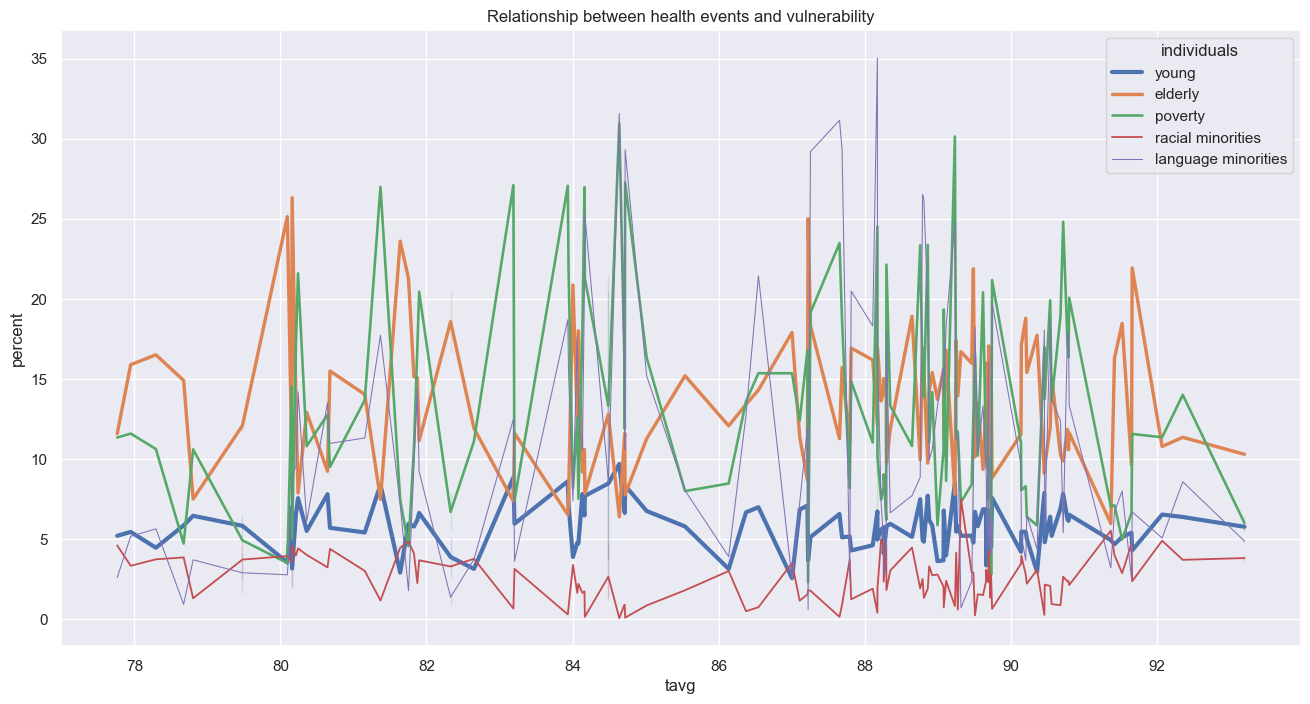

In [23]:
sns.set_theme()
fig,ax=plt.subplots()
ax=sns.lineplot(data=vuln_indi, x='tavg', y='percent', hue='individuals', size='individuals')
fig.set_size_inches((16,8))
ax.set_title('Relationship between health events and vulnerability')

In [24]:
vuln_indi

,census_city,individuals,percent,tmax,tmin,tavg
0,Acton,young,5.200000,103.62,75.016667,89.318333
1,Acton,elderly,16.700000,103.62,75.016667,89.318333
2,Acton,poverty,7.300000,103.62,75.016667,89.318333
3,Acton,racial minorities,7.500000,103.62,75.016667,89.318333
4,Acton,language minorities,0.700000,103.62,75.016667,89.318333
...,...,...,...,...,...,...
618,Woodland Hills,young,5.462500,106.45,73.840000,90.145000
619,Woodland Hills,elderly,17.120833,106.45,73.840000,90.145000
620,Woodland Hills,poverty,8.045833,106.45,73.840000,90.145000
621,Woodland Hills,racial minorities,3.966667,106.45,73.840000,90.145000


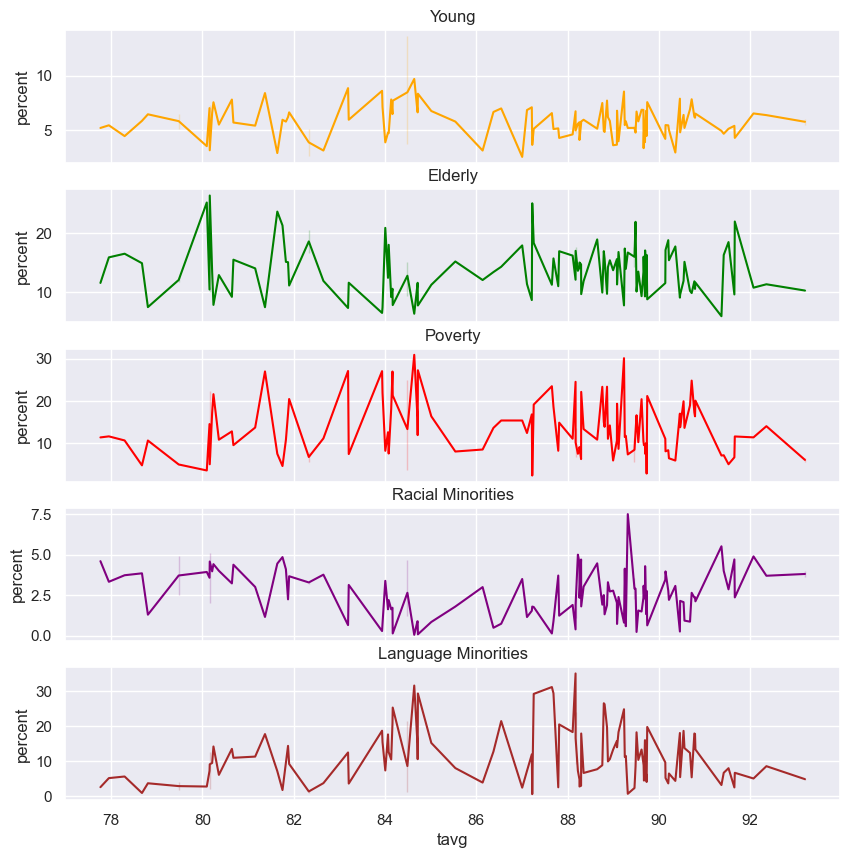

In [25]:
fig,axes=plt.subplots(5,sharex=True)
sns.lineplot(data=vuln_indi[vuln_indi.individuals=='young'], x='tavg', y='percent',ax=axes[0], color='orange')
sns.lineplot(data=vuln_indi[vuln_indi.individuals=='elderly'], x='tavg', y='percent',ax=axes[1], color='green')
sns.lineplot(data=vuln_indi[vuln_indi.individuals=='poverty'], x='tavg', y='percent',ax=axes[2], color='red')
sns.lineplot(data=vuln_indi[vuln_indi.individuals=='racial minorities'], x='tavg', y='percent',ax=axes[3], color='purple')
sns.lineplot(data=vuln_indi[vuln_indi.individuals=='language minorities'], x='tavg', y='percent',ax=axes[4], color='brown')
axes[0].set_title('Young')
axes[1].set_title('Elderly')
axes[2].set_title('Poverty')
axes[3].set_title('Racial Minorities')
axes[4].set_title('Language Minorities')
fig.set_size_inches(10,10)
